# PROTOTYPE UNIT-LINKED LIABILITIES

The purpose of this notebook is to showcase how unit-linked pension liabilities work inside the OSEM model,
using the same production classes and loop helpers that `main.py` calls when `liability_mode=unit_linked`.

Unit-linked products differ from the static cash-flow liability mode: they do **not** upload a pre-scheduled
outflow vector. Cash flows emerge each period from policy state (account value, premiums, fees) and
stochastic mortality / lapse liquidations.

Detailed methodology: `Documentation/Unit_Linked_Methodology.md` and `Liability_Dev/Unit_Linked_Methodology.html`.


In [1]:
import os
import pandas as pd
import datetime as dt
from pathlib import Path
import sys

base_folder = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "ALM.ini").is_file())
sys.path.insert(0, str(base_folder / "src"))
os.chdir(base_folder)


In [2]:
from osem.ConfigurationClass import Configuration
from osem.ImportData import (
    get_configuration,
    get_settings,
    get_unit_linked_policies,
    get_unit_linked_fund,
    get_society,
)
from osem.UnitLinkedClasses import UnitLinkedPolicy, UnitLinkedFund, UnitLinkedPortfolio
from osem.SocietyClass import Society
from osem.MainLoop import (
    capitalize_policies,
    apply_premiums,
    apply_admin_fees,
    apply_mortality,
    apply_lapse,
    process_unit_linked_period,
)


## Input files

Unit-linked runs need the usual ALM configuration plus three liability-specific files under `Input/`.


### Parameters.csv

Adds two fields used by the UL path:

- `liability_mode` ... `cashflow` (default) or `unit_linked`
- `random_seed` ... integer seed for reproducible mortality / lapse draws

Other parameters (modelling date, projection length, EIOPA files) are shared with the asset side.


### Unit_Linked_Policies.csv

In-force policy file at modelling date. Columns:

- `Policy_ID` ... unique identifier
- `Birth_Date` ... for age-based mortality (`dd/mm/yyyy`)
- `Is_Female` ... 0/1 selects mortality column
- `Is_Guaranteed` ... 0/1; if 1, GV is capitalized with MV
- `Premium` ... opening annual premium
- `MV` ... opening account / reserve value
- `GV` ... opening guaranteed value


### Unit_Linked_Fund.csv

Single-pool fund parameters (one row in the MVP):

- `Fund_ID`
- `Lapse_Rate` ... annual lapse probability
- `Admin_Fee` ... annual fee as share of MV
- `Entry_Fee` ... share of gross premium to insurer
- `Premium_Growth` ... annual premium growth rate


### mortality.csv

Age-indexed annual mortality rates with columns `AGE`, `MALE`, `FEMALE` (already used by `Society`).


Set up the base folder


In [3]:
base_folder = os.getcwd()  # Get current working directory

Most of the run settings are saved in the configuration file:


In [4]:
conf: Configuration
conf = get_configuration(os.path.join(base_folder, "ALM.ini"), os)

These lines of code extract the absolute locations of inputs:


In [5]:
parameters_file = conf.input_parameters
ul_policies_file = conf.input_unit_linked_policies
ul_fund_file = conf.input_unit_linked_fund
mortality_file = conf.input_mortality

In [6]:
paramfile = pd.read_csv("Input/Parameters.csv").set_index("Parameter")

In [7]:
display(paramfile)

,Value
Parameter,
EIOPA_param_file,Input/Param_no_VA.csv
EIOPA_curves_file,Input/Curves_no_VA.csv
country,Slovenia
run_type,Risk Neutral
n_proj_years,50
Precision,1E-10
Tau,0.0001
compounding,-1
Modelling_Date,29/04/2023


The settings object holds modelling date, projection horizon, liability mode, and random seed.

`liability_mode` only gates which liability branch `main.py` takes. This notebook calls the
unit-linked helpers directly, so it runs the same way whether the repository default in
`Input/Parameters.csv` is `cashflow` or `unit_linked` (see the last section for how to switch).


In [8]:
settings = get_settings(parameters_file)

In [9]:
print("modelling_date:", settings.modelling_date)

modelling_date: 2023-04-29


In [10]:
print("liability_mode:", settings.liability_mode)

liability_mode: cashflow


In [11]:
print("random_seed:", settings.random_seed)

random_seed: 42


In [12]:
print("end_date:", settings.end_date)

end_date: 2073-04-29


## Loading unit-linked objects

A Python generator reads the policy CSV into `UnitLinkedPolicy` instances keyed by `policy_id`.


In [13]:
policy_generator = get_unit_linked_policies(ul_policies_file)
ul_policies = {policy.policy_id: policy for policy in policy_generator}

Inspect a single policy (static metadata is frozen after import):


In [14]:
example_id = sorted(ul_policies.keys())[0]
policy = ul_policies[example_id]

In [15]:
display(ul_policies.keys())

dict_keys([1001, 1002, 1003, 1004, 1005])

In [16]:
print(policy)

UnitLinkedPolicy(policy_id=1001, birth_date=datetime.date(1970, 3, 15), is_female=True, is_guaranteed=False, premium=5000.0, mv=120000.0, gv=0.0)


In [17]:
print("Age at modelling date:", policy.age_at(settings.modelling_date))

Age at modelling date: 53


Fund parameters and mortality society:


In [18]:
ul_fund = get_unit_linked_fund(ul_fund_file)

In [19]:
display(ul_fund)

UnitLinkedFund(fund_id=1, lapse_rate=0.04, admin_fee=0.01, entry_fee=0.03, premium_growth=0.02)

In [20]:
society = get_society(mortality_file)

In [21]:
print("Male q at age 50:", society.mortality_rate(50, is_female=False))

Male q at age 50: 0.020122


In [22]:
print("Female q at age 50:", society.mortality_rate(50, is_female=True))

Female q at age 50: 0.009009


## Portfolio wrapper and state DataFrames

`UnitLinkedPortfolio` mirrors the equity/bond portfolio pattern. Simulation state lives in DataFrames
(rows = `policy_id`, columns = modelling dates), not on the frozen dataclasses.

There is no separate boolean "active" matrix: `init_policy_state_to_dataframe` returns just
`(mv_df, gv_df, premium_df)`, and a policy that dies or lapses has its row dropped from all three
(see `apply_mortality` / `apply_lapse` in steps 4-5 below) rather than being flagged inactive in place.

In [23]:
ul_ptf = UnitLinkedPortfolio(ul_policies)
ul_mv_df, ul_gv_df, ul_premium_df = ul_ptf.init_policy_state_to_dataframe(
    modelling_date=settings.modelling_date
)

In [24]:
print("Opening UL reserve:", ul_ptf.total_reserve(ul_mv_df, settings.modelling_date))

Opening UL reserve: 720000.0


In [25]:
display(ul_mv_df)

,2023-04-29
1001,120000.0
1002,250000.0
1003,75000.0
1004,180000.0
1005,95000.0


In [26]:
display(ul_premium_df)

,2023-04-29
1001,5000.0
1002,8000.0
1003,3000.0
1004,6000.0
1005,4500.0


In [27]:
print(f"{ul_mv_df.shape[0]} policies in force at the modelling date.")
print("There is no separate boolean active-flag matrix: a policy that later dies or lapses")
print("simply has its row dropped from mv_df / gv_df / premium_df (see steps 4-5 below).")

5 policies in force at the modelling date.
There is no separate boolean active-flag matrix: a policy that later dies or lapses
simply has its row dropped from mv_df / gv_df / premium_df (see steps 4-5 below).


## Dual cash accounts

- `bank_account` — fund / policyholder pool cash (flows into `trade()` in the full ALM run)
- `company_account` — insurer fee revenue (entry fee and admin fee; **not** passed through trading)

In this notebook we track toy cash balances to illustrate the methodology without running the full asset ALM loop.


In [28]:
previous_date = settings.modelling_date
bank_account = pd.DataFrame(data=[0.0], columns=[previous_date])
company_account = pd.DataFrame(data=[0.0], columns=[previous_date])

In [29]:
display(bank_account)

,2023-04-29
0,0.0


In [30]:
display(company_account)

,2023-04-29
0,0.0


## Period length

Modelling steps need not be exactly one year. OSEM uses the same convention as the asset side:

$$
\Delta t = \frac{currentDate - previousDate}{365.25}
$$

Annual fund rates and mortality are converted to the elapsed period (see steps below).


In [31]:
current_date = previous_date + dt.timedelta(days=365)
time_frac = (current_date - previous_date).days / 365.25

In [32]:
print("previous_date:", previous_date)

previous_date: 2023-04-29


In [33]:
print("current_date:", current_date)

current_date: 2024-04-28


In [34]:
print("time_frac:", time_frac)

time_frac: 0.999315537303217


## Where UL sits in the ALM main loop

In `main.py`, after equities/bonds are marked to market and `Portfolio return` is computed, and
**before** proportional `trade()`:

1. Capitalize MV (and GV if guaranteed) by the **period** portfolio return
2. Grow premiums; credit gross premium to `bank_account`; credit entry fee to `company_account`; add net to MV
3. Deduct admin fee from MV; credit `company_account`
4. Stochastic mortality (full MV liquidation if drawn)
5. Stochastic lapse on survivors
6. UL reserve = sum of active MV

This notebook uses an illustrative period return `r_period` (in the full run it comes from the asset portfolio).


In [35]:
# Illustrative period return from the asset MTM step in main.py
# (that value already embeds time_frac on the asset side)
r_period = 0.05
print("Illustrative portfolio_return (period factor):", r_period)


Illustrative portfolio_return (period factor): 0.05


## Step-by-step walkthrough

Carry forward previous state into the new date column, then apply each helper used by `process_unit_linked_period`.


In [36]:
# Working copies so cells remain re-runnable independently after reload
mv_df = ul_mv_df.copy()
gv_df = ul_gv_df.copy()
premium_df = ul_premium_df.copy()

mv_df[current_date] = mv_df[previous_date]
gv_df[current_date] = gv_df[previous_date]
premium_df[current_date] = premium_df[previous_date]
bank_account[current_date] = bank_account[previous_date]
company_account[current_date] = company_account[previous_date]

### 1) Capitalize

Active policies: 

$$
MV_t = MV_t * (1 + r_t)
$$

Where:
 - $r_t \dots $ is the calculated portfolio return at time $t$.
 - $MV^i_t \dots$ is the market value of the policy $i$ at time $t$.

Guaranteed policies also capitalize GV the same way.


In [37]:
print("MV before capitalize:")
display(mv_df[[previous_date, current_date]])

mv_df, gv_df = capitalize_policies(
    mv_df, gv_df, ul_policies, current_date, portfolio_return=r_period
)

print("MV after capitalize:")
display(mv_df[[current_date]])
print("GV after capitalize (guaranteed policies only change):")
display(gv_df[[current_date]])

MV before capitalize:


,2023-04-29,2024-04-28
1001,120000.0,120000.0
1002,250000.0,250000.0
1003,75000.0,75000.0
1004,180000.0,180000.0
1005,95000.0,95000.0


MV after capitalize:


,2024-04-28
1001,126000.0
1002,262500.0
1003,78750.0
1004,189000.0
1005,99750.0


GV after capitalize (guaranteed policies only change):


,2024-04-28
1001,0.0
1002,210000.0
1003,0.0
1004,0.0
1005,0.0


### 2) Premiums and entry fee

$$
P^{i, G}_t = P^{i, G}_{t-1} * (1 + pg_t)^{\Delta t}
$$

$$
F_t^{i,P} = P^{i, G}_t * f^{P}_t
$$

$$
P^{i, N}_t = P^{i, G}_t - F_t^{i,P}
$$

$$
b_t^c = b_t^c + F_t^{i,P}
$$

$$
MV_t^i = MV_t^i + P^{i, N}_t
$$

Where:
 - $pg_t \dots$ premium growth for the period $t$.
 - $\Delta t \dots$ is the time fraction or the length of the period (in years)
 - $P^{i, G}_t\dots$ is the gross premium for the policy $i$ at time $t$
 - $f^{P}_t \dots$ is the entry fee charged by the asset manager at time $t$
 - $F_t^{i,P} \dots$ is the size of the the entry fee, collected at time $t$ in policy $i$
 - $P^{i, N}_t \dots$ is the net premium for the policy $i$ at time $t$
 - $b_t^c \dots$ is the company bank account at time $t$ 
 - $MV_t^i \dots$ is the market value of policy $i$ at time $t$


In [38]:
mv_df, premium_df, gross_premium, entry_fee = apply_premiums(
    mv_df, premium_df, ul_fund, current_date, time_frac
)
bank_account[current_date] += gross_premium
company_account[current_date] += entry_fee

print("gross_premium:", gross_premium)
print("entry_fee (to company_account):", entry_fee)
print("bank_account:", float(bank_account.loc[0, current_date]))
print("company_account:", float(company_account.loc[0, current_date]))
display(mv_df[[current_date]])
display(premium_df[[current_date]])

gross_premium: 27029.633633546677
entry_fee (to company_account): 810.8890090064004
bank_account: 27029.633633546677
company_account: 810.8890090064004


,2024-04-28
1001,130946.932948
1002,270415.092717
1003,81718.159769
1004,194936.319538
1005,104202.239653


,2024-04-28
1001,5099.930874
1002,8159.889399
1003,3059.958525
1004,6119.917049
1005,4589.937787


### 3) Admin fee

Actual administration fee:

$$
adminFee_t = 1 - (1 - f^A_t)^{\Delta t}
$$


$$
F_t^{i, A} = MV^i_t * adminFee_t
$$

$$
MV^i_t = MV^i_t - F_t^{i, A} = MV^i_t * (1 - adminFee_t)
$$

$$
b_t^c = b_t^c + F_t^{i,A}
$$


Where:
 - $f^{A} \dots$ is the relative size of the administration fee (on a yearly basis)
 - $F_t^{i, A} \dots$ is the absolute size of the administration fee collected by the company
 - $adminFee_t \dots$ is the relative size of the administration fee given the length of the period $t$



In [39]:
mv_df, admin_fee = apply_admin_fees(mv_df, ul_fund, current_date, time_frac)
company_account[current_date] += admin_fee

print("admin_fee (to company_account):", admin_fee)
print("company_account:", float(company_account.loc[0, current_date]))
display(mv_df[[current_date]])

admin_fee (to company_account): 7816.860292067925
company_account: 8627.749301074326


,2024-04-28
1001,129638.355408
1002,267712.783401
1003,80901.534697
1004,192988.283920
1005,103160.926907


### 4) Mortality sampling (stochastic)

For each **active** policy (sorted by `policy_id`):

$$
mF_t^i = 1 - (1 - q^i_t)^{\Delta t}
$$

$u$ ~ Uniform(0, 1)

If the fund is guaranteed then: 
$$
b_t^f = b_t^f - max(MV_t^{i},GV_t^{i}) I_{u < mF_t^i }
$$

Otherwise:

$$
b_t^f = b_t^f - MV_t^{i} I_{u < mF_t^i }
$$

If the draw liquidates the policy it is **removed** from the state matrices entirely:
`mv_df`, `gv_df` and `premium_df` all drop that row. It is not zeroed in place, so a
liquidated policy cannot be charged a premium or a fee in any later period.


Where: 
 - $b_t^f \dots$ is the fund's own bank account
 - $mF_t^i \dots$ is the the probability, the client in policy $i$ dies within period $t$.
 - $q^i_t \dots$ is the probability that a person that is the same age as client in policy $i$ in the same year as the start of period $t$.

Using a forced RNG that always survives makes the path deterministic for teaching.


In [40]:
class AlwaysSurvive:
    def random(self):
        return 0.99

mv_df, gv_df, premium_df, death_total, deaths = apply_mortality(
    mv_df, gv_df, premium_df, ul_policies, society, current_date, time_frac, AlwaysSurvive()
)
bank_account[current_date] -= death_total

print("deaths:", deaths, "death_total:", death_total)
print("policies remaining in force:", mv_df.shape[0])
display(mv_df[[current_date]])

deaths: 0 death_total: 0.0
policies remaining in force: 5


,2024-04-28
1001,129638.355408
1002,267712.783401
1003,80901.534697
1004,192988.283920
1005,103160.926907


### 5) Lapse sampling (survivors only)

Same Bernoulli pattern with period-scaled `lapse_rate` on policies that remain active after mortality.

For each **active** policy (sorted by `policy_id`):

$$
lF_t^i = 1 - (1 - l_t)^{\Delta t}
$$

$u$ ~ Uniform(0, 1)

If the fund is guaranteed then: 
$$
b_t^f = b_t^f - max(MV_t^{i},GV_t^{i}) I_{u < lF_t^i }
$$

Otherwise:

$$
b_t^f = b_t^f - MV_t^{i} I_{u < lF_t^i }
$$

If the draw liquidates the policy it is **removed** from the state matrices entirely:
`mv_df`, `gv_df` and `premium_df` all drop that row. It is not zeroed in place, so a
liquidated policy cannot be charged a premium or a fee in any later period.


Where: 
 - $b_t^f \dots$ is the fund's own bank account
 - $lF_t^i \dots$ is the the probability, the client in policy $i$ lapses within period $t$.
 - $l_t \dots$ is the probability that a person lapses in the same year as the start of period $t$.





In [41]:
mv_df, gv_df, premium_df, surrender_total, lapses = apply_lapse(
    mv_df, gv_df, premium_df, ul_fund, current_date, time_frac, AlwaysSurvive()
)
bank_account[current_date] -= surrender_total

print("lapses:", lapses, "surrender_total:", surrender_total)
print("UL reserve:", ul_ptf.total_reserve(mv_df, current_date))
print("policies remaining in force:", mv_df.shape[0])
print("bank_account:", float(bank_account.loc[0, current_date]))
print("company_account:", float(company_account.loc[0, current_date]))

lapses: 0 surrender_total: 0.0
UL reserve: 774401.8843324725
policies remaining in force: 5
bank_account: 27029.633633546677
company_account: 8627.749301074326


## One-shot orchestrator (`process_unit_linked_period`)

The production helper carry-forwards state, runs steps 1–5, and returns cash-flow totals.
Signs for summary reporting are applied in `main.py` (benefits logged negative).


In [42]:
mv2, gv2, prem2 = ul_ptf.init_policy_state_to_dataframe(previous_date)

mv2, gv2, prem2, cfs = process_unit_linked_period(
    current_date=current_date,
    previous_date=previous_date,
    portfolio_return=r_period,
    time=time_frac,
    mv_df=mv2,
    gv_df=gv2,
    premium_df=prem2,
    policies=ul_policies,
    fund=ul_fund,
    society=society,
    random_seed=settings.random_seed,
    proj_period=0,
)

display(pd.Series(cfs, name="cashflows"))
print("UL reserve:", ul_ptf.total_reserve(mv2, current_date))
print("policies remaining in force:", mv2.shape[0])
display(mv2[[current_date]])

gross_premium     27029.633634
entry_fee           810.889009
admin_fee          7816.860292
death            267712.783401
surrender             0.000000
deaths                1.000000
lapses                0.000000
in_force              4.000000
Name: cashflows, dtype: float64

UL reserve: 506689.10093148355
policies remaining in force: 4


,2024-04-28
1001,129638.355408
1003,80901.534697
1004,192988.283920
1005,103160.926907


## Reproducibility

The same `random_seed` and `proj_period` produce the same draws. Different seeds can change liquidations.


In [43]:
def run_seeded(seed: int):
    mv, gv, prem = ul_ptf.init_policy_state_to_dataframe(previous_date)
    *_, cfs = process_unit_linked_period(
        current_date=current_date,
        previous_date=previous_date,
        portfolio_return=r_period,
        time=time_frac,
        mv_df=mv,
        gv_df=gv,
        premium_df=prem,
        policies=ul_policies,
        fund=ul_fund,
        society=society,
        random_seed=seed,
        proj_period=1,
    )
    return cfs["deaths"], cfs["lapses"], cfs["in_force"]

print("seed 42:", run_seeded(42))
print("seed 42 again:", run_seeded(42))
print("seed 99:", run_seeded(99))

seed 42: (0.0, 1.0, 4.0)
seed 42 again: (0.0, 1.0, 4.0)
seed 99: (0.0, 0.0, 5.0)


## Multi-period illustration

Roll several periods with a fixed illustrative return and the configuration seed. Track reserve,
company account, and policies in force.

`proj_period` counts completed periods and starts at 0, matching `main.py`, so that the draws
here reproduce those of a production run with the same seed.

The `Bank account` column goes deeply negative. That is an artifact of this standalone
illustration: there is no asset book here, so death and surrender payments are drawn from an
account that opens at zero and is never replenished by asset income or `trade()`. In a full
run the same flows are netted against the portfolio. Read it as a cumulative fund cash flow,
not as a balance.


,UL reserve,Company account,Bank account,In force,Deaths,Lapses,Gross premium
date,,,,,,,
2024-04-28,502036.068923,8555.798335,-238208.132742,4.0,1.0,0.0,27029.633634
2025-04-28,535382.796668,14537.391590,-218961.254499,4.0,0.0,0.0,19246.878242
2026-04-28,361389.714927,20880.823544,-408026.216153,2.0,0.0,2.0,19631.549716
2027-04-28,383522.924501,25109.310800,-396120.107919,2.0,0.0,0.0,11906.108233
2028-04-27,406539.946060,29577.272016,-383976.042125,2.0,0.0,0.0,12144.065794
2029-04-27,430471.513783,34294.081352,-371589.262908,2.0,0.0,0.0,12386.779217
2030-04-27,455349.363078,39269.436160,-358954.919357,2.0,0.0,0.0,12634.343552
2031-04-27,481206.262048,44513.367465,-346068.063605,2.0,0.0,0.0,12886.855751
2032-04-26,508076.043928,50036.250770,-332923.648902,2.0,0.0,0.0,13144.414704


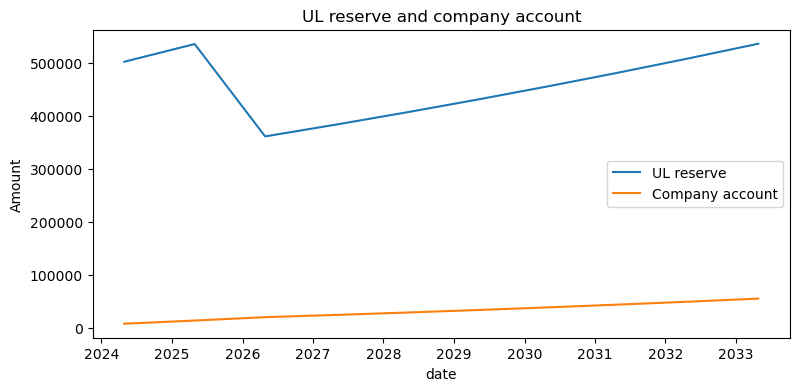

In [44]:
n_periods = 10
mv, gv, prem = ul_ptf.init_policy_state_to_dataframe(settings.modelling_date)
company = pd.DataFrame(data=[0.0], columns=[settings.modelling_date])
bank = pd.DataFrame(data=[0.0], columns=[settings.modelling_date])

history = []
prev = settings.modelling_date
for k in range(1, n_periods + 1):
    curr = prev + dt.timedelta(days=365)
    tf = (curr - prev).days / 365.25
    company[curr] = company[prev]
    bank[curr] = bank[prev]

    mv, gv, prem, cfs = process_unit_linked_period(
        current_date=curr,
        previous_date=prev,
        portfolio_return=0.04,
        time=tf,
        mv_df=mv,
        gv_df=gv,
        premium_df=prem,
        policies=ul_policies,
        fund=ul_fund,
        society=society,
        random_seed=settings.random_seed,
        proj_period=k - 1,
    )
    bank[curr] += cfs["gross_premium"] - cfs["death"] - cfs["surrender"]
    company[curr] += cfs["entry_fee"] + cfs["admin_fee"]

    history.append({
        "date": curr,
        "UL reserve": ul_ptf.total_reserve(mv, curr),
        "Company account": float(company.loc[0, curr]),
        "Bank account": float(bank.loc[0, curr]),
        "In force": cfs["in_force"],
        "Deaths": cfs["deaths"],
        "Lapses": cfs["lapses"],
        "Gross premium": cfs["gross_premium"],
    })
    prev = curr

history_df = pd.DataFrame(history).set_index("date")
display(history_df)

try:
    ax = history_df[["UL reserve", "Company account"]].plot(
        figsize=(9, 4), title="UL reserve and company account"
    )
    ax.set_ylabel("Amount")
except ImportError:
    print("Install matplotlib to plot this table (optional).")

## Connection to the full ALM run

In `src/osem/main.py` with `liability_mode=unit_linked`:

1. Assets still evolve first (dividends, coupons, growth, bond reprice).
2. `Portfolio return` from the asset book capitalizes UL accounts.
3. UL cash flows update `bank_account` and `company_account`.
4. Proportional `trade()` invests / disinvests using **fund** cash only (`company_account` is excluded).

Switch the mode in `Input/Parameters.csv`:

```
liability_mode,unit_linked
random_seed,42
```

Then run the model as a module (`python -m osem.main`, or the `osem` console script after
`pip install -e .`) and inspect `Output/Results.csv` for the UL summary columns.

Run this notebook from the repository root so `ALM.ini` and `Input/` resolve correctly.


## Out of scope for this MVP

New business, lifecycle fund migration, full DCF reserving, company-account payouts,
morbidity / retirement, and multi-fund asset buckets are not modelled yet.
